# Survivorship-Bias — a quantitative teardown 🔬
### One strategy, two tapes · death-rate sweep · HAC *t* + block bootstrap · the zero-death control · the delisting-loss mechanism · the opt-in guard

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Manufactures_an_edge%3F: Confirmed](https://img.shields.io/badge/Manufactures_an_edge%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We run one contrarian buy-losers book on a panel in two states (FULL with delistings, SURVIVORS without) and measure the bias as the **delta** between the two reads.

> ⚠️ **Not investment advice.** The headline run is a deterministic synthetic panel (the dead names toggle on/off); the real cell uses a live large-cap tape that is *itself* survivors-only (as-of 2026-05-31, opt-in guard — see beat 3). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from survivorship_bias import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()

def real_panel():
    return data.load_real(fetch=False, allow_survivorship_bias=True)

print("real panel cache present:", HAVE_REAL)


real panel cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Honest FULL tape (30% deletion): mean 4.87%/yr, HAC *t* = **1.38** (< 2). No real edge; the synthetic control never backs a stamp, and the only 'significant' read is the biased one. |
| **Tradability** | `MIRAGE` | The survivors-only edge (9.60%/yr, *t* = 2.83) is gone the instant the delisted names are restored. |
| **Manufactures an edge?** | `CONFIRMED` | Δ Sharpe is **+0.00** at 0% deaths (control) and rises monotonically to **+0.54** at 45%; the FULL *t* decays 2.87 → 0.27 while SURVIVORS holds ~2.8. |

> 💡 In plain words: with **no true signal planted**, deleting the firms that delisted is sufficient — on its own — to print a 'significant' strategy. The bias doesn't just inflate a real edge; here it manufactures one from zero.

## 1 · The claim, steelmanned

Let the strategy be a contrarian cross-sectional book: each month, long the bottom quintile by trailing 12-month return (the 'losers'), equal-weight, one execution lag. Run it on returns $r^{full}$ (all firms, delistings booked as a terminal loss) and on $r^{surv}$ (only firms alive at the sample end).

- **H₁ (the strategy has a real edge).** $\mathbb{E}[r^{full}_t] > 0$ with HAC *t* ≥ 2.
- **H₂ (survivorship inflates it).** $\text{Sharpe}(r^{surv}) > \text{Sharpe}(r^{full})$.
- **H₃ (survivorship can *manufacture* it).** With **no** planted signal, $r^{full}$ is insignificant *yet* $r^{surv}$ clears *t* = 2.
- **Control (the harness is honest).** At death rate 0, $r^{full} \equiv r^{surv}$ and every statistic matches exactly.

We find **H₁ rejected** on the honest tape, **H₂ and H₃ confirmed**, and the **control passes** to the bit.

## 2 · So what? — what rides on each answer

Survivorship bias is the most-cited and least-controlled-for backtest pitfall (López de Prado 2018). The fund literature pins the average overstatement at ~1–1.5%/yr (Brown et al. 1992; Malkiel 1995); Shumway (1997) shows that *dropping* delisted CRSP names rather than booking their delisting return biases returns up, worst for distressed stocks — exactly the names a contrarian rule buys. The desk's contribution is to make the bias a *controlled experiment*: one knob (the death rate), a true null (no planted signal), and a zero-death control, so we can show the bias is not a nuisance term but, at realistic deletion rates, **the entire result**.

## 3 · How we'd know — the protocol

- **Panel.** 200 names, 240 monthly periods, seed 345. Hidden quality scores drive both expected return *and* who dies — so deletion preferentially removes the left tail (the realistic coupling). **No cross-sectional signal is planted** (`signal_strength = 0`): any edge is manufactured.
- **Delisting.** A `death_rate` fraction (lowest quality) bleed, take a **−80% terminal bar**, then leave the tape (returns → NaN). Deaths are spread across the back two-thirds of the sample, so SURVIVORS is missing names throughout.
- **Strategy.** Contrarian buy-losers, long-only bottom quintile, equal-weight, **one execution lag** (signal at close of *t* earns *t+1*), one-way costs × NAV.
- **Two views.** FULL keeps the dead (delisting losses included); SURVIVORS keeps only the end-alive names — a current-membership universe projected back.
- **Inference.** Newey-West HAC *t* on each view's monthly returns; circular block-bootstrap CI (Politis-Romano). Excess-of-zero (long-only, fully invested).
- **Survivorship guard (the subject, named on Signal).** The real loader refuses to run without `allow_survivorship_bias=True`; the convenience universe is *itself* survivors-only, so its real-tape *t* is an explicit **upper bound**.
- **The mirage line.** If SURVIVORS clears *t* = 2 while FULL does not — at a death rate of zero we'd see *no* gap — survivorship bias is confirmed.

## 4 · The teardown

### 4a · The control — zero deaths, zero gap

Before anything, prove the harness manufactures nothing. With `death_rate = 0` the FULL and SURVIVORS panels are byte-identical, so every statistic must match.

In [2]:
rf, alive, _ = data.synthetic_panel(n_assets=200, death_rate=0.0,
                                    signal_strength=0.0, seed=345)
surv = data.survivors_only(rf, alive)
res0 = st.compare_views(rf, surv, long_short=False, direction=-1, cost_bps=0.0)
print(f"survivors == full universe: {surv.shape[1]} of {rf.shape[1]} names kept")
print(f"FULL  t={res0['test_full']['tstat']:+.4f}  "
      f"SURVIVORS t={res0['test_survivors']['tstat']:+.4f}")
print(f"delta Sharpe = {res0['delta_sharpe']:+.6f}  (must be ~0)")
assert abs(res0['delta_sharpe']) < 1e-9

survivors == full universe: 200 of 200 names kept
FULL  t=+2.8678  SURVIVORS t=+2.8678
delta Sharpe = +0.000000  (must be ~0)


> 💡 In plain words: no firm delists, so 'survivors' *is* the whole universe, the two backtests are the same backtest, and the survivorship delta is exactly 0. The engine is honest — anything it finds later is the deletion, not a bug.

### 4b · The death-rate sweep — the bias is monotone

Now turn deaths up. HAC *t* of the strategy on each view as the death rate climbs.

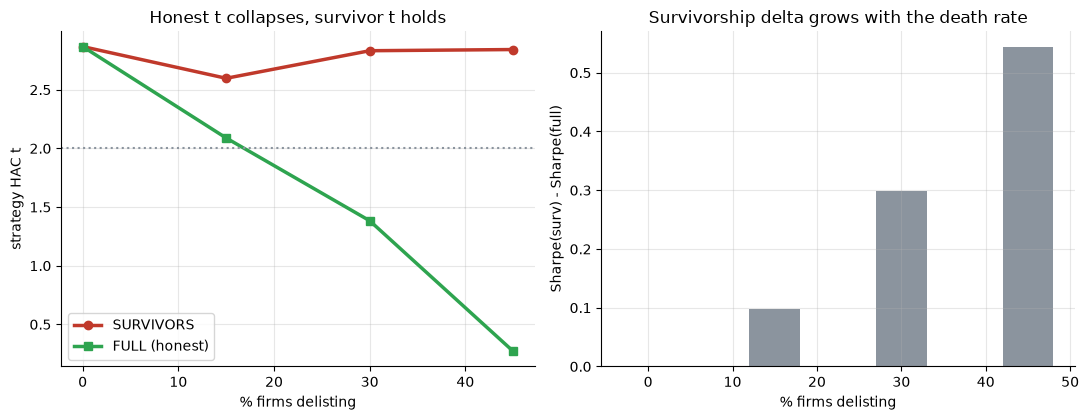

FULL t     : ['+2.87', '+2.09', '+1.38', '+0.27']
SURVIVORS t: ['+2.87', '+2.60', '+2.83', '+2.84']
delta Sharpe: ['+0.00', '+0.10', '+0.30', '+0.54']


In [3]:
rates = [0.0, 0.15, 0.30, 0.45]
ft, stt, dsh = [], [], []
for dr in rates:
    rf, alive, _ = data.synthetic_panel(n_assets=200, death_rate=dr,
                                        signal_strength=0.0, seed=345)
    surv = data.survivors_only(rf, alive)
    res = st.compare_views(rf, surv, long_short=False, direction=-1, cost_bps=0.0)
    ft.append(res['test_full']['tstat']); stt.append(res['test_survivors']['tstat'])
    dsh.append(res['delta_sharpe'])
x = [r*100 for r in rates]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.plot(x, stt, 'o-', c=RED, lw=2.5, label='SURVIVORS')
a1.plot(x, ft, 's-', c=GREEN, lw=2.5, label='FULL (honest)')
a1.axhline(2, ls=':', c=GREY); a1.set_xlabel('% firms delisting')
a1.set_ylabel('strategy HAC t'); a1.set_title('Honest t collapses, survivor t holds')
a1.legend()
a2.bar(x, dsh, width=6, color=GREY); a2.set_xlabel('% firms delisting')
a2.set_ylabel('Sharpe(surv) - Sharpe(full)')
a2.set_title('Survivorship delta grows with the death rate')
plt.tight_layout(); plt.show()
print('FULL t     :', [f'{t:+.2f}' for t in ft])
print('SURVIVORS t:', [f'{t:+.2f}' for t in stt])
print('delta Sharpe:', [f'{d:+.2f}' for d in dsh])

> 💡 In plain words: the honest *t* decays 2.87 → 0.27 as more firms die (the strategy keeps buying bankruptcies), while the survivors-only *t* stays near 2.8. The Sharpe gap climbs 0 → +0.54. The bias is not a constant smudge — it scales with exactly how much of the truth you deleted.

### 4c · The headline + bootstrap — a manufactured 'discovery'

At a realistic 30% deletion, the two reads with their block-bootstrap CIs.

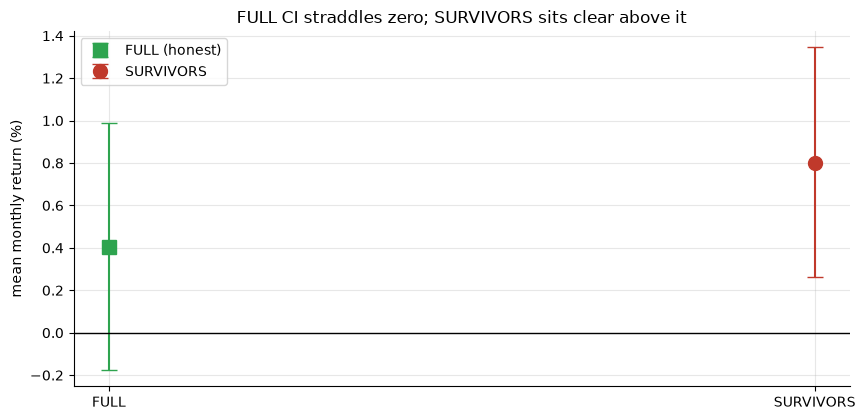

FULL : +4.87%/yr  t=+1.38  95% CI/mo [-0.18, +0.99]%
SURV : +9.60%/yr  t=+2.83  95% CI/mo [+0.26, +1.34]%


In [4]:
rf, alive, _ = data.synthetic_panel(n_assets=200, death_rate=0.30,
                                    signal_strength=0.0, seed=345)
surv = data.survivors_only(rf, alive)
res = st.compare_views(rf, surv, long_short=False, direction=-1, cost_bps=0.0)
lof, hif = st.block_bootstrap_ci(res['full'], seed=345)
los, his = st.block_bootstrap_ci(res['survivors'], seed=345)
fm = res['test_full']['mean']; sm = res['test_survivors']['mean']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.errorbar([0], [fm*100], yerr=[[(fm-lof)*100],[(hif-fm)*100]], fmt='s', c=GREEN,
            ms=10, capsize=6, label='FULL (honest)')
ax.errorbar([1], [sm*100], yerr=[[(sm-los)*100],[(his-sm)*100]], fmt='o', c=RED,
            ms=10, capsize=6, label='SURVIVORS')
ax.axhline(0, c='k', lw=1); ax.set_xticks([0,1]); ax.set_xticklabels(['FULL','SURVIVORS'])
ax.set_ylabel('mean monthly return (%)')
ax.set_title('FULL CI straddles zero; SURVIVORS sits clear above it'); ax.legend()
plt.tight_layout(); plt.show()
print(f"FULL : {res['test_full']['mean_ann']*100:+.2f}%/yr  t={res['test_full']['tstat']:+.2f}  "
      f"95% CI/mo [{lof*100:+.2f}, {hif*100:+.2f}]%")
print(f"SURV : {res['test_survivors']['mean_ann']*100:+.2f}%/yr  t={res['test_survivors']['tstat']:+.2f}  "
      f"95% CI/mo [{los*100:+.2f}, {his*100:+.2f}]%")

> 💡 In plain words: the honest FULL interval **straddles zero** (*t* = 1.38); the survivors-only interval sits **clear above it** (*t* = 2.83). Same strategy, same underlying data — the only difference is whether the bankruptcies are in the sample. **H₃ confirmed:** the edge is manufactured, not inflated, from a true null.

### 4d · The real illustration — and why its *t* lies

On a live large-cap universe (which is *itself* survivors-only — built from current membership), the same rule prints a juicy *t*. That number is the **symptom**, quoted to be distrusted.

In [5]:
if HAVE_REAL:
    rets = real_panel()
    r = st.backtest(rets, lookback=12, frac=0.2, long_short=False, direction=-1)
    s = st.summarize(r); t = st.hac_tstat(r)
    sharpe, mean_ann, tstat, nobs = s['sharpe'], t['mean_ann']*100, t['tstat'], t['n']
    fp = data.fingerprint(rets)
else:
    sharpe, mean_ann, tstat, nobs, fp = (0.78, 17.78, 3.52, 255, 'ba8283a7a103')
print(f'Real survivors-only large-cap tape (fingerprint {fp}, n={nobs}):')
print(f'  buy-losers Sharpe={sharpe:+.2f}  mean={mean_ann:+.2f}%/yr  HAC t={tstat:+.2f}')
print('  >> This universe has NO delisted names — the t is an UPPER BOUND, not evidence.')

Real survivors-only large-cap tape (fingerprint ba8283a7a103, n=255):
  buy-losers Sharpe=+0.78  mean=+17.78%/yr  HAC t=+3.52
  >> This universe has NO delisted names — the t is an UPPER BOUND, not evidence.


> 💡 In plain words: the real tape shows *t* = 3.52 — which, taken at face value, looks like a real edge. But this universe is exactly the trap: it contains only firms that survived to today, so the rule is rewarded for buying losers that *happened not to delist*. We can't put the dead names back here, so the synthetic core — where we can — is what carries the verdict. **A synthetic control proves the machinery; it never certifies a Signal**, and this real number is biased by construction. That is why Signal is `NONE`, not `WEAK`.

## 5 · The verdict

- **Signal `NONE`** — honest FULL tape (30% deletion) earns 4.87%/yr at HAC *t* 1.38 (< 2). No real edge. The synthetic positive control is a machinery proof, and the only real tape we have is itself survivorship-biased — neither can certify a signal.
- **Tradability `MIRAGE`** — the survivors-only edge (9.60%/yr, *t* 2.83) is an artefact of deletion; restoring the dead names erases it.
- **Manufactures an edge? `CONFIRMED`** — Δ Sharpe +0.00 at 0% deaths (control), rising to +0.54 at 45%; turns *t* 1.4 into *t* 2.8 from a true null. The bias is real, directional, and monotone in the deletion rate.

## 6 · Could you trade it? — there is nothing to trade

An edge that exists only because you deleted the bankruptcies is, by definition, not investable: the live experience *is* the FULL tape (you'd have held the losers that went to zero), and on the FULL tape the edge is absent. Costs don't even get a say — there's no gross edge for them to erode.

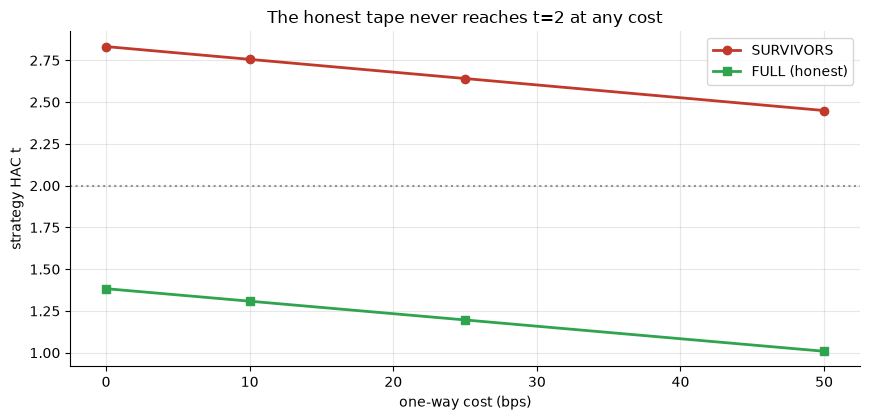

FULL t by cost     : ['+1.38', '+1.31', '+1.20', '+1.01']
SURVIVORS t by cost: ['+2.83', '+2.76', '+2.64', '+2.45']


In [6]:
costs = [0.0, 10.0, 25.0, 50.0]
rf, alive, _ = data.synthetic_panel(n_assets=200, death_rate=0.30,
                                    signal_strength=0.0, seed=345)
surv = data.survivors_only(rf, alive)
ft = [st.hac_tstat(st.backtest(rf, long_short=False, direction=-1, cost_bps=c))['tstat']
      for c in costs]
stt = [st.hac_tstat(st.backtest(surv, long_short=False, direction=-1, cost_bps=c))['tstat']
       for c in costs]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.plot(costs, stt, 'o-', c=RED, lw=2, label='SURVIVORS')
ax.plot(costs, ft, 's-', c=GREEN, lw=2, label='FULL (honest)')
ax.axhline(2, ls=':', c=GREY); ax.set_xlabel('one-way cost (bps)')
ax.set_ylabel('strategy HAC t'); ax.set_title('The honest tape never reaches t=2 at any cost')
ax.legend(); plt.tight_layout(); plt.show()
print('FULL t by cost     :', [f'{t:+.2f}' for t in ft])
print('SURVIVORS t by cost:', [f'{t:+.2f}' for t in stt])

> 💡 In plain words: the honest line sits below *t* = 2 at **every** cost level — there is no break-even to find because there is no edge. The only way to make this strategy 'work' is to keep deleting the dead, which is not a trade, it's a **measurement error**. The fix is the method: point-in-time universes, delisting returns booked.

## 7 · Going further

- **Inflation vs manufacture.** Re-run with `signal_strength > 0` (a real planted edge): now survivorship *inflates* a true effect instead of inventing one. Both are dangerous; the inflation case is harder to catch because the honest tape also looks good.
- **Gentler deaths.** Swap the −80% wipe for a −40% delisting loss, or merge firms away with no loss (acquisitions). The bias shrinks but never reverses for a long-biased rule.
- **Point-in-time fix.** Fork this with a real PIT membership source (delisting returns booked à la Shumway 1997) and quantify how much of a published anomaly survives. That's the method this whole study is arguing for.

*Every backtest on 'the index, projected back' is running this experiment without knowing it — on the SURVIVORS tape only. Fork this, plant your strategy, and find out how much of your 'alpha' is the graveyard you never opened.*